# 식수 인원 예측 고도화 및 데이터 실험 (V6)

이 버전에서는 `train_median.csv` 데이터를 기반으로, 메뉴의 의미를 더 깊게 파악하기 위한 **Target Encoding**과 월급날 패턴(`payday`) 등 고급 피처 엔지니어링을 적용합니다.
또한, 단일 모델과 앙상블 모델의 성능을 비교 분석합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import korean_font
korean_font.set_korean_font()

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


## 1. 데이터 로드 및 고급 피처 엔지니어링

In [2]:
train = pd.read_csv('data/train_median.csv')
test = pd.read_csv('data/test.csv')
weather = pd.read_csv('data/weather.csv')
submission = pd.read_csv('data/sample_submission.csv')

def preprocess_v6(df, weather_df):
    df['일자'] = pd.to_datetime(df['일자'])
    weather_df['일시'] = pd.to_datetime(weather_df['일시'])
    
    # 기상 통합
    w_sub = weather_df[['일시', '기온', '강수량']].copy()
    w_sub.columns = ['일시', 'temp', 'rain']
    df = pd.merge(df, w_sub, left_on='일자', right_on='일시', how='left')
    
    df['temp'] = df['temp'].fillna(df['temp'].mean())
    df['is_rain'] = df['rain'].fillna(0).apply(lambda x: 1 if x > 0 else 0)
    
    # 날짜 및 월급날 피처
    df['month'] = df['일자'].dt.month
    df['day'] = df['일자'].dt.day
    df['weekday'] = df['일자'].dt.weekday
    df['dist_payday'] = df['day'].apply(lambda x: abs(x - 25))
    
    # 인원
    df['in_office'] = df['본사정원수'] - df['본사휴가자수'] - df['본사출장자수'] - df['현본사소속재택근무자수']
    return df

train = preprocess_v6(train, weather)
test = preprocess_v6(test, weather)

def parse_menu(menu_series):
    bob, soup, main = [], [], []
    for menu_str in menu_series:
        items = str(menu_str).split()
        clean = [x for x in items if '(' not in x]
        bob.append(clean[0] if len(clean) > 0 else 'None')
        soup.append(clean[1] if len(clean) > 1 else 'None')
        main.append(clean[2] if len(clean) > 2 else 'None')
    return bob, soup, main

train['lunch_bob'], train['lunch_soup'], train['lunch_main'] = parse_menu(train['중식메뉴'])
train['dinner_bob'], train['dinner_soup'], train['dinner_main'] = parse_menu(train['석식메뉴'])
test['lunch_bob'], test['lunch_soup'], test['lunch_main'] = parse_menu(test['중식메뉴'])
test['dinner_bob'], test['dinner_soup'], test['dinner_main'] = parse_menu(test['석식메뉴'])

train['lunch_cnt'] = train['중식메뉴'].apply(lambda x: len(str(x).split()))
test['lunch_cnt'] = test['중식메뉴'].apply(lambda x: len(str(x).split()))

## 2. K-Fold Target Encoding
메뉴 범주형 변수를 타겟 값(식수 인원)의 평균으로 인코딩하여 수치적 의미를 부여합니다. 과적합 방지를 위해 K-Fold 방식을 사용합니다.

In [3]:
def kfold_target_encode(train_df, test_df, cat_cols, target_col):
    train_res, test_res = train_df.copy(), test_df.copy()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for col in cat_cols:
        train_res[f'{col}_te'] = 0.0
        for t_idx, v_idx in kf.split(train_df):
            mapping = train_df.iloc[t_idx].groupby(col)[target_col].mean()
            train_res.loc[train_df.index[v_idx], f'{col}_te'] = train_df.iloc[v_idx][col].map(mapping)
        test_res[f'{col}_te'] = test_df[col].map(train_df.groupby(col)[target_col].mean())
        fill_val = train_df[target_col].mean()
        train_res[f'{col}_te'] = train_res[f'{col}_te'].fillna(fill_val)
        test_res[f'{col}_te'] = test_res[f'{col}_te'].fillna(fill_val)
    return train_res, test_res

l_cols = ['lunch_bob', 'lunch_soup', 'lunch_main']
train_l, test_l = kfold_target_encode(train, test, l_cols, '중식계')

train_dinner = train[train['석식계'] > 0].copy() # 석식 없는 날 제외
d_cols = ['dinner_bob', 'dinner_soup', 'dinner_main']
train_d, test_d = kfold_target_encode(train_dinner, test, d_cols, '석식계')

## 3. 모델 비교 및 앙상블 학습
단일 XGBoost 모델과 XGB+LGBM+CAT 가중치 앙상블의 성능을 비교합니다.

In [4]:
features_l = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', 'temp', 'is_rain', 'lunch_cnt', 'dist_payday'] + [c+'_te' for c in l_cols]
features_d = ['weekday', 'month', 'day', 'in_office', '본사시간외근무명령서승인건수', 'temp', 'is_rain', 'dist_payday'] + [c+'_te' for c in d_cols]

def train_v6(X, y, test_X, target_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    import lightgbm as lgb
    
    models = {
        'XGB': XGBRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42, early_stopping_rounds=50),
        'LGBM': LGBMRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, colsample_bytree=0.7, random_state=42, verbosity=-1),
        'CAT': CatBoostRegressor(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=42, verbose=0, early_stopping_rounds=50)
    }
    
    oofs, preds = {}, {}
    for name, model in models.items():
        oof = np.zeros(len(X))
        pred = np.zeros(len(test_X))
        for t_idx, v_idx in kf.split(X, y):
            if name == 'LGBM': model.fit(X.iloc[t_idx], y.iloc[t_idx], eval_set=[(X.iloc[v_idx], y.iloc[v_idx])], eval_metric='mae', callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            else: model.fit(X.iloc[t_idx], y.iloc[t_idx], eval_set=[(X.iloc[v_idx], y.iloc[v_idx])], verbose=False)
            oof[v_idx] = model.predict(X.iloc[v_idx])
            pred += model.predict(test_X) / 5
        oofs[name], preds[name] = oof, pred
        print(f"{name} {target_name} MAE: {mean_absolute_error(y, oof):.4f}")
    
    # Weighted Ensemble
    inv_maes = {n: 1.0/mean_absolute_error(y, oofs[n]) for n in models.keys()}
    w = {n: inv_maes[n]/sum(inv_maes.values()) for n in models.keys()}
    ens_oof = sum(oofs[n] * w[n] for n in models.keys())
    ens_pred = sum(preds[n] * w[n] for n in models.keys())
    print(f"Ensemble {target_name} MAE: {mean_absolute_error(y, ens_oof):.4f}")
    
    return ens_pred, ens_oof, y, preds['XGB']

p_l_ens, o_l_ens, y_l, p_l_xgb = train_v6(train_l[features_l], train_l['중식계'], test_l[features_l], "Lunch")
p_d_ens, o_d_ens, y_d, p_d_xgb = train_v6(train_d[features_d], train_d['석식계'], test_d[features_d], "Dinner")

XGB Lunch MAE: 78.8004
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[286]	valid_0's l1: 79.5999	valid_0's l2: 10893.8
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[360]	valid_0's l1: 88.6946	valid_0's l2: 12810.3
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[206]	valid_0's l1: 76.7142	valid_0's l2: 10784.6
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[263]	valid_0's l1: 75.2989	valid_0's l2: 10489.5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[122]	valid_0's l1: 80.5626	valid_0's l2: 10759
LGBM Lunch MAE: 80.1740
CAT Lunch MAE: 78.6044
Ensemble Lunch MAE: 78.3459
XGB Dinner MAE: 52.1912
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	valid_0's l1: 59.2558	valid_0's l2: 6407.64
Trai

## 4. 예측 결과 비교 시각화
앙상블 모델과 단일 모델(XGB)의 예측값 분포를 비교하여 차이를 분석합니다.

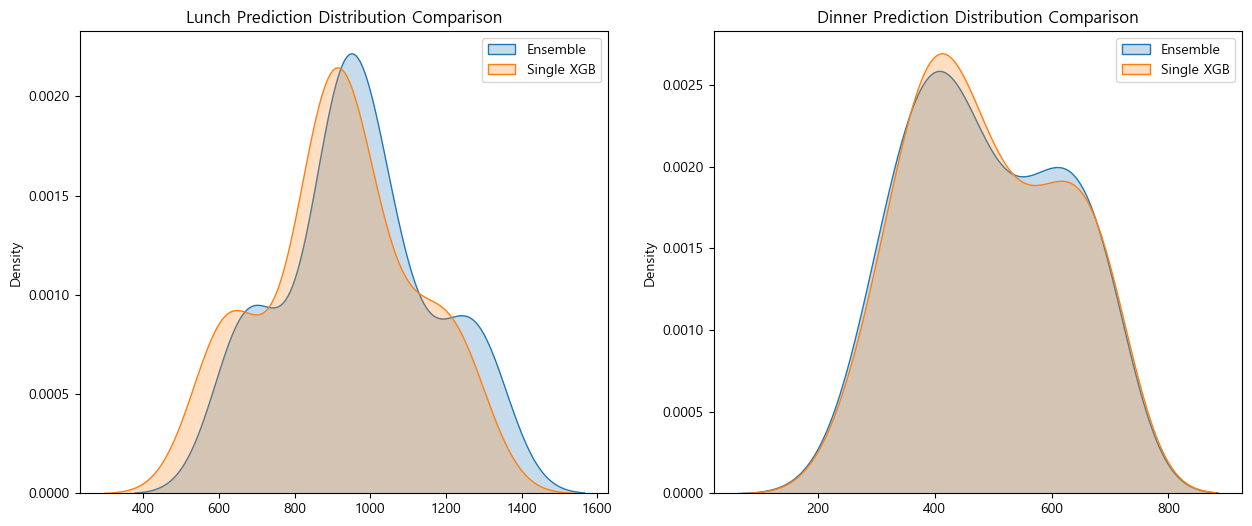

In [5]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(p_l_ens, label='Ensemble', shade=True)
sns.kdeplot(p_l_xgb, label='Single XGB', shade=True)
plt.title('Lunch Prediction Distribution Comparison')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(p_d_ens, label='Ensemble', shade=True)
sns.kdeplot(p_d_xgb, label='Single XGB', shade=True)
plt.title('Dinner Prediction Distribution Comparison')
plt.legend()
plt.show()

## 5. 최종 결과 저장

In [6]:
submission['중식계'] = p_l_ens
submission['석식계'] = p_d_ens
submission.to_csv('submission/dining_submission_v6.csv', index=False)
print("Optimization V6 Complete.")

Optimization V6 Complete.
